In [200]:
# Задача
# 1. Сгенерируйте набор данных для предсказания временных последовательностей. Выполните тренировку RNN
# 2. Модифицируйте сеть, используя в качестве рекуррентного слоя LSTM слой библиотеки pytorch.
# https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html

Генерация данных

In [201]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

seq_length = 20
num_sequences = 100
total_time_steps = num_sequences * (seq_length + 1)
time_steps = np.linspace(0, num_sequences * np.pi, total_time_steps)
data = np.sin(time_steps)
data = data.reshape((num_sequences, seq_length + 1, 1))

In [202]:
train_data = data[:80]
test_data = data[80:]

RNN модель

In [203]:
class RNN(nn.Module):
    def __init__(self, input_size, output_size, hidden_dim, n_layers):
        super(RNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.rnn = nn.RNN(input_size, hidden_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_size)

    def forward(self, x, hidden):
        r_out, hidden = self.rnn(x, hidden)
        r_out = r_out.view(-1, self.hidden_dim)
        output = self.fc(r_out)
        return output, hidden


In [204]:
input_size = 1
output_size = 1
hidden_dim = 32
n_layers = 1

rnn = RNN(input_size, output_size, hidden_dim, n_layers)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(rnn.parameters(), lr=0.01)

def train_rnn(rnn, train_data, n_steps=1000, print_every=100):
    print('Результаты обучения RNN')
    rnn.train()
    hidden = None

    for step in range(n_steps):
        seq_idx = np.random.randint(0, len(train_data))
        seq = train_data[seq_idx]
        
        x_tensor = torch.Tensor(seq[:-1]).unsqueeze(0)
        y_tensor = torch.Tensor(seq[1:])

        prediction, hidden = rnn(x_tensor, hidden)
        hidden = hidden.data

        loss = criterion(prediction, y_tensor)
        optimizer.zero_grad()
        loss.backward(retain_graph=True)
        optimizer.step()

        if step % print_every == 0:
            print(f'Step {step}, Loss: {loss.item():.4f}')

    
train_rnn(rnn, train_data)
rnn.eval()
test_input = torch.Tensor(test_data[0][:-1]).unsqueeze(0)
test_output_rnn, _ = rnn(test_input, None)

Результаты обучения RNN
Step 0, Loss: 0.3229
Step 100, Loss: 0.0314
Step 200, Loss: 0.0095
Step 300, Loss: 0.0053
Step 400, Loss: 0.0034
Step 500, Loss: 0.0063
Step 600, Loss: 0.0009
Step 700, Loss: 0.0059
Step 800, Loss: 0.0093
Step 900, Loss: 0.0019


LSTM модель

In [205]:
class LSTM(nn.Module):
    def __init__(self, input_size, output_size, hidden_dim, n_layers):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_size, hidden_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_size)

    def forward(self, x, hidden):
        r_out, hidden = self.lstm(x, hidden)
        r_out = r_out.view(-1, self.hidden_dim)
        output = self.fc(r_out)
        return output, hidden

In [206]:
lstm = LSTM(input_size, output_size, hidden_dim, n_layers)
optimizer_lstm = torch.optim.Adam(lstm.parameters(), lr=0.01)

def train_lstm(lstm, train_data, n_steps=1000, print_every=100):
    print('Результаты обучения LSTM')
    lstm.train()
    hidden = (torch.zeros(n_layers, 1, hidden_dim), torch.zeros(n_layers, 1, hidden_dim))

    for step in range(n_steps):
        seq_idx = np.random.randint(0, len(train_data))
        seq = train_data[seq_idx]
        
        x_tensor = torch.Tensor(seq[:-1]).unsqueeze(0)
        y_tensor = torch.Tensor(seq[1:])

        prediction, hidden = lstm(x_tensor, hidden)
        
        hidden = (hidden[0].detach(), hidden[1].detach())
        
        loss = criterion(prediction, y_tensor)
        optimizer_lstm.zero_grad()
        
        loss.backward(retain_graph=True)
        optimizer_lstm.step()

        if step % print_every == 0:
            print(f'Step {step}, Loss: {loss.item():.4f}')

train_lstm(lstm, train_data)
lstm.eval()
test_output_lstm, _ = lstm(test_input, (torch.zeros(n_layers, 1, hidden_dim), torch.zeros(n_layers, 1, hidden_dim)))


Результаты обучения LSTM
Step 0, Loss: 0.5112
Step 100, Loss: 0.0026
Step 200, Loss: 0.0019
Step 300, Loss: 0.0003
Step 400, Loss: 0.0053
Step 500, Loss: 0.0025
Step 600, Loss: 0.0077
Step 700, Loss: 0.0014
Step 800, Loss: 0.0070
Step 900, Loss: 0.0010


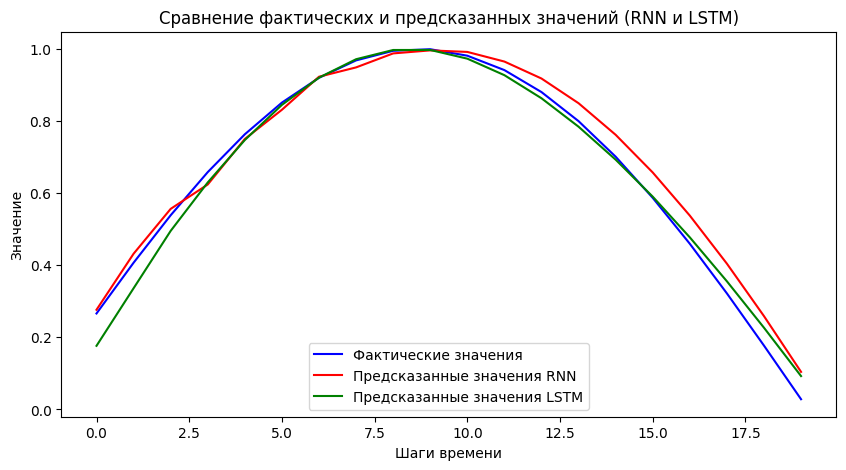

In [207]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(seq_length), test_data[0][1:], 'b', label='Фактические значения')
plt.plot(np.arange(seq_length), test_output_rnn.data.numpy(), 'r', label='Предсказанные значения RNN')
plt.plot(np.arange(seq_length), test_output_lstm.data.numpy(), 'g', label='Предсказанные значения LSTM')
plt.title('Сравнение фактических и предсказанных значений (RNN и LSTM)')
plt.xlabel('Шаги времени')
plt.ylabel('Значение')
plt.legend()
plt.show()

In [208]:
# Задание (файл 2)
# Разделить данные на N групп. (возможно, выбрать первые M данных для обучения)
# Реализовать предсказание ARIMA для 2 (тренировочной группы) на основе 1. Рассчитать MSE.
# Исследовать качество работы модели в зависимости от параметров (для групп 1-2).
# (1)Выполнить итеративное предсказание, данные для каждого следующего предсказания обновлять по методу
# "экспоненциальное среднее".

In [209]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings

In [210]:
df = pd.read_csv('ETTm1.csv')
x = df['OT']

In [211]:
N = 2
groups = np.array_split(df, N)

train_data = groups[0].OT
test_data = groups[1].OT
test_data

34840    20.118999
34841    19.979000
34842    19.344999
34843    19.697001
34844    19.344999
           ...    
69675     9.567000
69676     9.567000
69677     9.426000
69678     9.426000
69679     9.778000
Name: OT, Length: 34840, dtype: float64

Исследуем качество работы модели в зависимости от параметров

In [212]:
def change_params(train_data, test_data):
    results = []
    best_mse = float('inf')
    best_order = None
    best_model = None

    warnings.filterwarnings("ignore")

    for p in range(1, 4): 
        for d in range(1, 3):
            for q in range(1, 4):
                try:
                    model = ARIMA(train_data, order=(p, d, q))
                    fitted_model = model.fit()
                    start = len(train_data)
                    end = len(train_data) + len(test_data) - 1
                    predictions = fitted_model.predict(start=start, end=end)
                    
                    mse = mean_squared_error(test_data, predictions)
                    
                    results.append({'p': p, 'd': d, 'q': q, 'MSE': mse})
                    
                    if mse < best_mse:
                        best_mse = mse
                        best_order = (p, d, q)
                        best_model = fitted_model
                except Exception:
                    continue
    
    results_df = pd.DataFrame(results).sort_values(by='MSE')
    return best_model, best_order, best_mse, results_df

Перебор параметров p, d, q:
    p  d  q         MSE
10  2  2  2   46.217499
5   1  2  3   46.307816
11  2  2  3   46.977193
16  3  2  2   49.629648
4   1  2  2   52.820624
3   1  2  1   55.772721
15  3  2  1   61.703875
9   2  2  1   73.164871
0   1  1  1  136.672179
12  3  1  1  136.965990
6   2  1  1  136.992284
13  3  1  2  137.150988
1   1  1  2  137.208701
8   2  1  3  137.210263
7   2  1  2  137.217731
2   1  1  3  137.252153
14  3  1  3  137.432302
17  3  2  3  535.333614

Лучшие параметры ARIMA: (2, 2, 2) с MSE: 46.21750


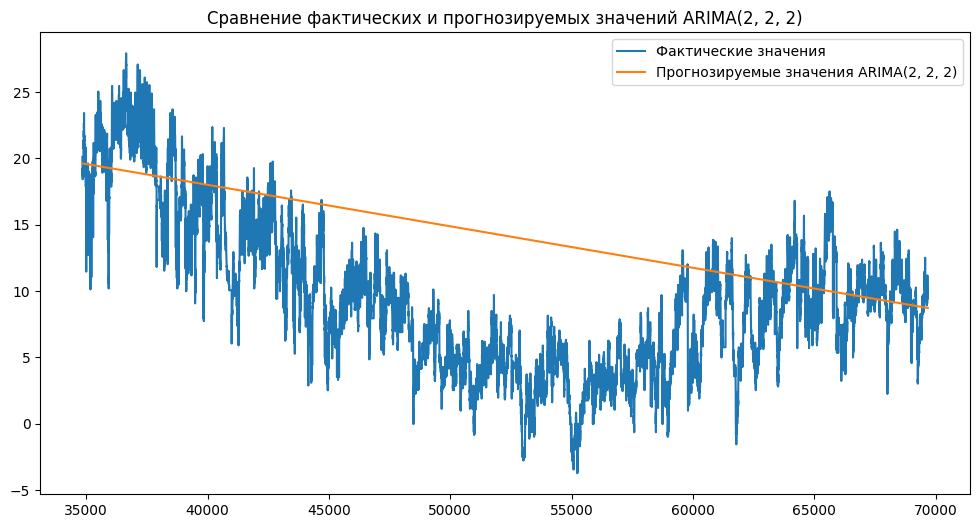

In [213]:
best_model, best_order, best_mse, results_df = change_params(train_data, test_data)

print("Перебор параметров p, d, q:")
print(results_df)

print(f"\nЛучшие параметры ARIMA: {best_order} с MSE: {best_mse:.5f}")

start = len(train_data)
end = len(train_data) + len(test_data) - 1
predictions = best_model.predict(start=start, end=end)

plt.figure(figsize=(12, 6))
plt.plot(test_data, label='Фактические значения')
plt.plot(predictions, label=f'Прогнозируемые значения ARIMA{best_order}')
plt.legend()
plt.title(f'Сравнение фактических и прогнозируемых значений ARIMA{best_order}')
plt.show()

Итеративное предсказание

In [215]:
alpha = 0.5

model = ARIMA(train_data, order=(1, 0, 0)).fit()
predictions = []
forecast_result = model.forecast(steps=1)


current_prediction = forecast_result[0] if isinstance(forecast_result, (list, np.ndarray)) else forecast_result.iloc[0]

for i in range(len(test_data)):
    true_value = test_data.iloc[i]
    predictions.append(current_prediction)
    current_prediction = alpha * true_value + (1 - alpha) * current_prediction

mse = mean_squared_error(test_data, predictions)
print(f'MSE: {mse}')


MSE: 0.18063080410607038
